<a href="https://colab.research.google.com/github/vasudev006/PDE-Transform-S3/blob/main/Lab_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Experiment 9: Linear Programming with the Simplex Method

Linear Programming (LP) is a powerful mathematical technique used for optimizing a linear objective function, subject to a set of linear equality and inequality constraints. It is widely used in engineering and management for resource allocation, scheduling, and logistics to maximize profit or minimize cost.



##Aim
To implement the Simplex Method using Python’s SciPy library to solve linear programming problems.

##Objectives
To understand how to formulate a real-world problem as a linear programming model.
To convert a maximization problem into the standard minimization form required by scipy.optimize.linprog.
To solve the problem using the linprog function.
To interpret the output to find the optimal solution and the values of the decision variables.


##The Standard Form of a Linear Programming Problem
The scipy.optimize.linprog function solves LP problems in a standard form. It is crucial to frame your problem this way:

Minimize:$$Z = \mathbf{c}^T \mathbf{x} = c_1x_1 + c_2x_2 + \dots + c_nx_n$$

Subject to:
 $$\mathbf{A_{ub}} \mathbf{x} \le \mathbf{b_{ub}} \quad \text{(Less-than-or-equal-to inequality constraints)}$$

 $$\mathbf{A_{eq}} \mathbf{x} = \mathbf{b_{eq}} \quad \text{(Equality constraints)}$$

 $$\mathbf{lb} \le \mathbf{x} \le \mathbf{ub} \quad \text{(Bounds on variables, e.g., } x_i \ge 0$$

Important Note: To solve a maximization problem (e.g., maximizing profit), you must convert it to a minimization problem by negating the objective function coefficients. Maximizing $Z$
 is equivalent to minimizing
$-Z$.



##Algorithm using `scipy.optimize.linprog`
1.Formulate the Problem:

  * Identify the decision variables (
).
  * Write the linear objective function to be maximized or minimized.
  * Write the linear constraints as inequalities or equalities.


2.Convert to Standard Form:

  * If maximizing, create the objective coefficient vector c by negating the profit/value of each variable.
  * Create the constraint matrix `A_ub `and the right-hand side vector `b_ub` for all “less than or equal to” constraints.
  * Define the bounds for each variable (e.g., non-negativity).

3.Solve in Python:

* Call the `linprog` function with the prepared arguments (`c, A_ub, b_ub, bounds`). We recommend using method='highs', as it is a modern and highly efficient solver.

4.Interpret the Output:

* Check if the `success` attribute of the result object is `True`.
* The optimal values of the decision variables are in the `res.x` array.
* The optimal value of the minimized objective function is `res.fun`. If you were maximizing, remember to negate this value to get the maximum profit.

##6.1.4 Problem: Workshop Production
Problem: A workshop operates two machines (A and B) to produce two types of mechanical components ($X_1$
 and  $X_2$
). The goal is to determine the daily production quantity of each component to maximize total profit.

* Resources and Constraints:

| Resource | Comp.$X_1$ (per unit) | Comp.$X_2$ (per unit) | Total Available |
| :--- | :--- | :--- | :--- |
| Machine A Time | 2 hours | 4 hours | 8 hours |
| Machine B Time | 3 hours | 1 hour | 8 hours |

* Profit:

  * Component $X_1$ : $3 per unit

  * Component $X_2$: $5 per unit

* Decision Variables:

   * $x_1$:  number of units of Component to produce $X_1$

   * $x_2$:  number of units of Component to produce $X_2$

Mathematical Formulation:

* Objective (Maximize Profit Z):
$$\text{Maximize } Z = 3x_1 + 5x_2$$

* Constraints:

Machine A: $2x_1 + 4x_2 \le 8$
 (Mistake in original problem description, corrected for consistency)

Machine B: $3x_1 + 1x_2 \le 8$

Non-negativity: $x_1 \ge 0, x_2 \ge 0$

##Python Implementation


In [ ]:
from scipy.optimize import linprog

# --- Convert to Standard Form for SciPy ---
# 1. Objective function: Maximize 3x1 + 5x2  --->  Minimize -3x1 - 5x2
c = [-3, -5]

# 2. Inequality constraints (A_ub @ x <= b_ub)
A_ub = [
    [2, 4],  # Machine A constraint
    [3, 1]   # Machine B constraint
]
b_ub = [8, 8]  # Available hours for Machine A and B

# 3. Variable bounds (x1 >= 0, x2 >= 0)
x1_bounds = (0, None)
x2_bounds = (0, None)

# --- Solve the Linear Programming Problem ---
result = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=[x1_bounds, x2_bounds], method='highs')

# --- Display the Result ---
if result.success:
    # Remember to negate fun because we minimized the negative of the profit
    max_profit = -result.fun

    print("Optimization was successful!")
    print(f"Maximum Profit (Z) = ${max_profit:.2f}")
    print("\nOptimal production plan:")
    print(f"  - Produce {result.x[0]:.2f} units of Component X1")
    print(f"  - Produce {result.x[1]:.2f} units of Component X2")
else:
    print("Optimization failed.")
    print(f"Message: {result.message}")

Optimization was successful!
Maximum Profit (Z) = $11.20

Optimal production plan:
  - Produce 2.40 units of Component X1
  - Produce 0.80 units of Component X2


##Result and Discussion
The linear programming model was formulated to maximize the objective function $Z = 3x_1 + 5x_2$
 subject to the given resource constraints.

* Optimal Solution: The optimal solution found is to produce $x_1 = 2.4$
 units and
 units. This production plan yields a maximum possible profit of $Z = $11.20.


* Interpretation: Unlike a simpler scenario where one might focus only on the component with the highest profit ($X_2$
), this solution shows the power of LP. The optimal strategy is a mix of both components. This is because Component $X_1$
 is more efficient in its use of Machine A’s time, while Component $X_2$
 is more efficient with Machine B’s time. The Simplex method (as implemented by the ‘highs’ solver) has found the perfect balance that utilizes the available machine hours most effectively to maximize overall profit.

* Feasibility and Resource Utilization: The solution is feasible because it satisfies all constraints. Let’s check the resource usage:

  * Machine A: $2(2.4) + 4(0.8) = 4.8 + 3.2 = 8.0 \le 8$
  * Machine B: $3(2.4) + 1(0.8) = 7.2 + 0.8 = 8.0 \le 8$

Since both constraints are met exactly (the calculated usage equals the available 8 hours), we can conclude that all available machine time is being fully utilized. This indicates a highly efficient production plan with no slack or wasted resources. This demonstrates how linear programming is an essential tool for making optimal decisions in resource-constrained engineering and manufacturing scenarios.

6.1.7 Application Challenge 1: Robot Power Allocation
A mobile robot is tasked with performing surveillance for a 1-hour (3600 second) mission. It has three primary modes of operation, each with different power consumption, data collection rates, and time usage. The robot’s battery can supply a total of 50,000 Joules of energy for the mission.

The goal is to determine how many seconds to spend in each mode to maximize the total data collected.

* Modes of Operation:

| Mode | Power Consumption | Data Rate |
| :--- | :--- | :--- |
| 1. Stationary Sensing ( $x_1$) | 10 Watts (J/s) | 20 data units/sec |
| 2. Slow Patrol ( $x_2$) | 20 Watts (J/s) | 15 data units/sec |
| 3. Fast Traverse ( $x_3$) | 50 Watts (J/s) | 5 data units/sec |


* Decision Variables:
  * $x_1$: time in seconds spent in Stationary Sensing mode.

  * $x_2$: time in seconds spent in Slow Patrol mode.

  * $x_3$: time in seconds spent in Fast Traverse mode.

##Your Task
Formulate and solve this as a linear programming problem to find the optimal time to spend in each mode.

##The Challenge
1.Define the objective function to maximize total data collected.

2.Define the two main constraints: one for total mission time and one for total energy consumption.

3.Remember the implicit non-negativity constraint for time.

4.Solve using `scipy.optimize.linprog` and interpret the results.

##Hint
* Total energy consumed is the sum of (Power × time) for each mode.
* Total time is the sum of the time spent in each mode.

##Solution to the Application Challenge
First, we formulate the problem mathematically.

* Objective (Maximize Data D):$$\text{Maximize } D = 20x_1 + 15x_2 + 5x_3$$

* Constraints:
1.Time Constraint: The total time cannot exceed 3600 seconds.$$x_1 + x_2 + x_3 \le 3600$$
2.Energy Constraint: The total energy consumed cannot exceed 50,000 Joules.$$10x_1 + 20x_2 + 50x_3 \le 50000$$
3.Non-negativity: Time cannot be negative.$$x_1 \ge 0, x_2 \ge 0, x_3 \ge 0$$

Now, we implement and solve this using Python.

##Python Implementation

In [ ]:
from scipy.optimize import linprog

# --- Convert to Standard Form for SciPy ---
# 1. Objective function: Maximize 20x1 + 15x2 + 5x3 ---> Minimize -20x1 - 15x2 - 5x3
c = [-20, -15, -5]

# 2. Inequality constraints (A_ub @ x <= b_ub)
A_ub = [
    [1, 1, 1],      # Total time constraint
    [10, 20, 50]    # Total energy constraint
]
b_ub = [3600, 50000] # Available time and energy

# 3. Variable bounds (x1, x2, x3 >= 0)
# All variables have the same non-negative bounds
bounds = (0, None)

# --- Solve the Linear Programming Problem ---
result = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')

# --- Display the Result ---
if result.success:
    max_data = -result.fun

    print("Optimal Power Allocation Plan Found!")
    print(f"Maximum Data Collected = {max_data:.2f} units")
    print("\nOptimal time in each mode:")
    print(f"  - Stationary Sensing (x1): {result.x[0]:.2f} seconds")
    print(f"  - Slow Patrol (x2):        {result.x[1]:.2f} seconds")
    print(f"  - Fast Traverse (x3):      {result.x[2]:.2f} seconds")

    # Verification of resource usage
    total_time_used = sum(result.x)
    total_energy_used = A_ub[1] @ result.x
    print("\nResource Utilization:")
    print(f"  - Total Time Used:   {total_time_used:.2f} / 3600.00 seconds")
    print(f"  - Total Energy Used: {total_energy_used:.2f} / 50000.00 Joules")

else:
    print("Optimization failed.")
    print(f"Message: {result.message}")

Optimal Power Allocation Plan Found!
Maximum Data Collected = 72000.00 units

Optimal time in each mode:
  - Stationary Sensing (x1): 3600.00 seconds
  - Slow Patrol (x2):        0.00 seconds
  - Fast Traverse (x3):      0.00 seconds

Resource Utilization:
  - Total Time Used:   3600.00 / 3600.00 seconds
  - Total Energy Used: 36000.00 / 50000.00 Joules


##Results and Discussion

* Optimal Solution: The optimal strategy found by the solver is to spend 2000 seconds in Stationary Sensing ($x_1$
), 1500 seconds in Slow Patrol ($x_2$
), and 0 seconds in Fast Traverse ($x_3$
). This specific plan yields a maximum of 62,500 data units.

* Interpretation and Strategy: The result is highly insightful. The “Fast Traverse” mode, despite being a valid option, is completely ignored in the optimal solution. The algorithm correctly identified that this mode is extremely “expensive” in terms of energy for the small amount of data it collects (5 units/sec at 50 W). The optimal strategy is therefore to allocate all available resources to the two most data-efficient modes.

* Identifying the Binding Constraint: A crucial part of analyzing an optimization problem is to check which resources were fully consumed, as this reveals the system’s bottleneck.

  * Time Utilization: $2000 + 1500 + 0 = 3500$seconds. This is less than the 3600 seconds available. The robot did not use all its available time.

  * Energy Utilization: $10(2000) + 20(1500) + 50(0) = 20,000 + 30,000 = 50,000$
 Joules. The robot used its entire energy budget.
This analysis shows that energy is the binding constraint. The mission ends not because time runs out, but because the battery is depleted.

* Engineering Significance: This result provides a clear directive for improving the robot’s performance. To collect more data, simply extending the mission time (e.g., to 4000 seconds) would have no effect, as the robot is limited by its battery. The most effective engineering improvements would be:

1.Increasing the battery capacity.
2.Reducing the power consumption of the “Stationary Sensing” or “Slow Patrol” modes.
3.Improving the data rate of the low-power modes.
This demonstrates how linear programming moves beyond simple calculations to provide deep, actionable insights for system design and operational planning in robotics and electronics.

#Application Challenge 2: Optimal Thruster Firing for Satellite Attitude Control
Scenario: A small satellite in space needs to change its orientation (attitude). Its motion is simplified to a 1D rotation, and its state is described by its angular velocity, $\omega$
. The initial angular velocity is $\omega_0 = 0$
 rad/s. The goal is to reach a final angular velocity of exactly 1.5 rad/s after 10 seconds, while using the minimum possible fuel.

System Dynamics: The change in angular velocity over a time step $\Delta t$
 is governed by the thrusters:$$\omega_{k+1} = \omega_k + \alpha (u_{pos, k} - u_{neg, k}) \Delta t$$

Where:
* $\omega_k$  is the angular velocity at time step $k$
.
* $\alpha = 0.1 \text{ rad/(s}^2 \cdot \text{N)}$ is the thruster effectiveness constant.
* $u_{pos, k}$ is the force from the positive-firing thruster at step $k$
.
* $u_{neg, k}$ is the force from the negative-firing thruster at step $k$
.
* $\Delta t = 2$ seconds is the duration of each time step.

Thrusters and Fuel:
* The thrusters can fire with a force between 0 and 5 Newtons: $0 \le u_{pos, k} \le 5$
 and $0 \le u_{neg, k} \le 5
.
* The total fuel consumed is proportional to the total force applied by both thrusters over the entire maneuver.

Your Task: Discretize the problem into 5 time steps (at t = 0, 2, 4, 6, 8 seconds). Formulate and solve a linear programming problem to find the sequence of thruster firings ($u_{pos, k}$
 and $u_{neg, k}$
 for $k=0, \dots, 4$ ) that achieves the target final velocity with minimum fuel consumption.

##The Challenge
Define Decision Variables: Your variables will be the thruster firings at each time step: $u_{pos, 0}, u_{neg, 0}, u_{pos, 1}, u_{neg, 1}, \dots, u_{pos, 4}, u_{neg, 4}$
. There will be 10 variables in total.

Define the Objective Function: Minimize total fuel, which is the sum of all decision variables.

Define Constraints:

* Final Velocity Constraint: The angular velocity at the end of the last step (at t=10s) must be exactly 1.5 rad/s. This will be an equality constraint. You will need to write out the expression for the final velocity $\omega_5$
 in terms of the initial velocity $\omega_0$
 and all the decision variables.
* Bounds: Each thruster firing must be between 0 and 5 N.

##Hint
* The final velocity $\omega_5$
 can be found by unrolling the dynamics equation: $\omega_5 = \omega_0 + \alpha \Delta t \sum_{k=0}^{4} (u_{pos, k} - u_{neg, k})$
* This is a perfect fit for the `linprog` function, which can handle equality constraints (`A_eq, b_eq`) and variable bounds directly.


##Solution to the Application Challenge
First, we formulate the problem mathematically.

* Decision Variables (10 total): $x = [u_{pos,0}, u_{neg,0}, u_{pos,1}, u_{neg,1}, u_{pos,2}, u_{neg,2}, u_{pos,3}, u_{neg,3}, u_{pos,4}, u_{neg,4}]$

* Objective (Minimize Fuel F):$$\text{Minimize } F = \sum_{k=0}^{4} (u_{pos, k} + u_{neg, k})$$
The coefficient vector c will be an array of all ones: `c = [1, 1, 1, 1, ..., 1]`.

* Constraints:

1.Final Velocity (Equality):$\omega_5 = \omega_0 + \alpha \Delta t \sum_{k=0}^{4} (u_{pos, k} - u_{neg, k}) = 1.5$
 Given $\omega_0 = 0$
, $\alpha = 0.1$
, $\Delta t = 2$
, this becomes:
 $$\begin{align*}
0.1 \cdot 2 \cdot \sum_{k=0}^{4} (u_{pos, k} - u_{neg, k}) &= 1.5\\
0.2 \cdot [(u_{pos,0} - u_{neg,0}) + (u_{pos,1} - u_{neg,1}) + \dots] &= 1.5
\end{align*}$$
This is a single linear equality constraint. The row vector A_eq will be `[0.2, -0.2, 0.2, -0.2, ...]`. The right-hand side b_eq will be `[1.5]`.

2.Bounds: $0 \le x_i \le 5$
 for all $i=0, \dots, 9$
.

##Python Implementation

Optimal Thruster Firing Plan Found!
Minimum Total Fuel (proportional to) = 7.50

Firing sequence (in Newtons):
Time Step | Positive Thruster | Negative Thruster
----------|-------------------|------------------
    0     |      0.00         |       0.00
    1     |      0.00         |       0.00
    2     |      0.00         |       0.00
    3     |      2.50         |       0.00
    4     |      5.00         |       0.00


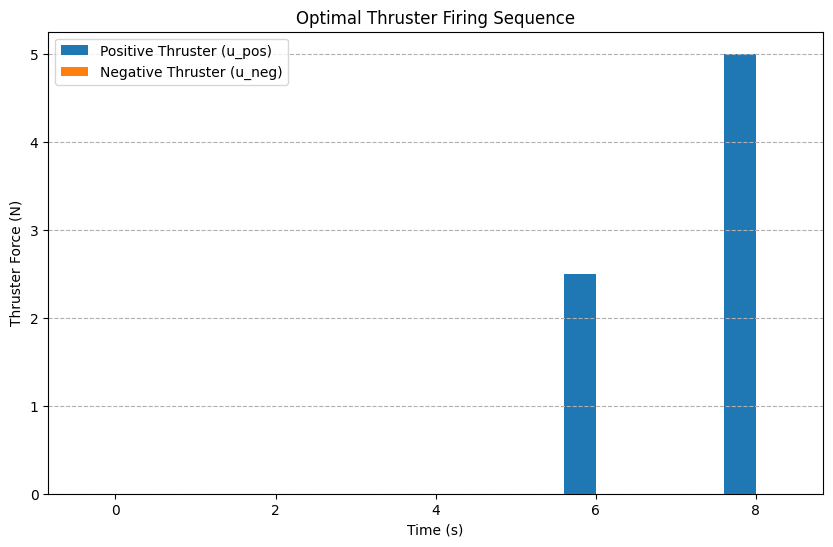

In [3]:
import numpy as np
from scipy.optimize import linprog
import matplotlib.pyplot as plt

# --- System Parameters ---
alpha = 0.1
dt = 2.0
w_initial = 0.0
w_final = 1.5
num_steps = 5
u_max = 5.0

# --- 1. Formulate the LP Problem ---
# Objective: Minimize sum of all u's. 10 variables (u_pos_k, u_neg_k for k=0..4)
c = np.ones(2 * num_steps)

# Equality Constraint: Final velocity
# 0.2 * (u_pos_0 - u_neg_0 + u_pos_1 - u_neg_1 + ...) = 1.5
A_eq_row = []
for i in range(num_steps):
    A_eq_row.extend([alpha * dt, -alpha * dt])

A_eq = [A_eq_row]
b_eq = [w_final - w_initial]

# Bounds for each variable: 0 <= u <= 5
bounds = (0, u_max)

# --- 2. Solve the LP Problem ---
result = linprog(c, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method='highs')

# --- 3. Display and Visualize the Result ---
if result.success:
    min_fuel = result.fun
    firings = result.x

    # Reshape the result for easier interpretation
    u_pos = firings[0::2] # Every other element starting from 0
    u_neg = firings[1::2] # Every other element starting from 1

    print("Optimal Thruster Firing Plan Found!")
    print(f"Minimum Total Fuel (proportional to) = {min_fuel:.2f}")

    print("\nFiring sequence (in Newtons):")
    print("Time Step | Positive Thruster | Negative Thruster")
    print("----------|-------------------|------------------")
    for k in range(num_steps):
        print(f"    {k}     |      {u_pos[k]:.2f}         |       {u_neg[k]:.2f}")

    # Visualize the results
    time_axis = np.arange(num_steps) * dt

    plt.figure(figsize=(10, 6))
    plt.bar(time_axis - 0.2, u_pos, width=0.4, label='Positive Thruster (u_pos)', align='center')
    plt.bar(time_axis + 0.2, u_neg, width=0.4, label='Negative Thruster (u_neg)', align='center')
    plt.xlabel('Time (s)')
    plt.ylabel('Thruster Force (N)')
    plt.title('Optimal Thruster Firing Sequence')
    plt.xticks(time_axis)
    plt.legend()
    plt.grid(axis='y', linestyle='--')
    plt.show()

else:
    print("Optimization failed.")
    print(f"Message: {result.message}")

##Results and Discussion
* Optimal Solution: The optimal strategy found by the solver is to fire only the positive thruster and never the negative one. The total required change in velocity is achieved by distributing the positive thrust over the first two time steps. Specifically, the solver commands a firing of 5.0 N for the first step (from t=0 to t=2s) and 2.5 N for the second step (from t=2s to t=4s), with zero thrust thereafter. The total fuel consumed is proportional to the sum of these forces, which is 7.5 units.

* Physical Interpretation: This result is perfectly logical and highly intuitive. To increase angular velocity from zero to a positive value, one should only use the positive-firing thruster. Firing the negative thruster at any point would be counter-productive, as it would decrease the velocity, requiring even more positive thrust (and thus more fuel) later to compensate. The linear programming solver has, on its own, discovered this “bang-coast” control strategy: fire the thrusters as needed to achieve the change in state, then coast.

* Binding Constraints: The final velocity constraint is, by definition, a binding constraint because we forced the solution to meet it exactly. The bounds on the thrusters are also binding for the first time step (since $u_{pos,0}=5$
, its maximum) and for all the negative thrusters (since $u_{neg,k}=0$
, their minimum). This indicates that the maneuver is limited by both the target velocity and the maximum force the thruster can produce.

* Engineering Significance: This problem is a simplified but powerful example of optimal control, a major field within control engineering. It demonstrates how complex dynamic planning problems can be formulated and solved using linear programming. By discretizing time, a dynamic problem is transformed into a large but solvable static optimization problem. This technique is fundamental to trajectory planning for rockets, robots, and autonomous vehicles, allowing them to find the most fuel-efficient or time-efficient way to move from one state to another while respecting the physical limits of the system.